In [13]:
import gdsfactory as gf

FLOORPLAN = (64, 0)
DICING = (65, 0)

DIE_W = 7850
DIE_H = 3000
DICING_W = 100

EDGE_MARGIN = 150          # keep components away from die edge
DICE_CLEARANCE = 100       # keep components away from dicing street


def add_floorplan(chip: gf.Component) -> None:
    """Adds filled die floorplan rectangle."""
    chip.add_polygon(
        [
            (0, 0),
            (DIE_W, 0),
            (DIE_W, DIE_H),
            (0, DIE_H),
        ],
        layer=FLOORPLAN,
    )


def add_vertical_dicing_street(
    chip: gf.Component,
    x_center: float,
) -> None:
    """Adds a vertical 100 um dicing street from bottom to top die edge."""
    x0 = x_center - DICING_W / 2
    x1 = x_center + DICING_W / 2

    chip.add_polygon(
        [
            (x0, 0),
            (x1, 0),
            (x1, DIE_H),
            (x0, DIE_H),
        ],
        layer=DICING,
    )


def check_ref_inside_region(
    ref,
    name: str,
    xmin: float,
    xmax: float,
    ymin: float,
    ymax: float,
) -> None:
    """Raises an error if a placed reference does not fit in its allowed region."""
    if ref.xmin < xmin or ref.xmax > xmax or ref.ymin < ymin or ref.ymax > ymax:
        raise ValueError(
            f"{name} does not fit in its assigned floorplan region.\n"
            f"{name} bbox: "
            f"x=[{ref.xmin:.1f}, {ref.xmax:.1f}], "
            f"y=[{ref.ymin:.1f}, {ref.ymax:.1f}]\n"
            f"Allowed region: "
            f"x=[{xmin:.1f}, {xmax:.1f}], "
            f"y=[{ymin:.1f}, {ymax:.1f}]"
        )


def make_wdm_tx_rx_floorplan(
    tx_component: gf.Component,
    rx_component: gf.Component,
) -> gf.Component:
    chip = gf.Component()

    # Add die floorplan
    add_floorplan(chip)

    # Put the dicing street at the die center.
    # This splits the die into a left TX region and right RX region.
    x_dice = DIE_W / 2
    add_vertical_dicing_street(chip, x_center=x_dice)

    # Define usable placement regions
    left_xmin = EDGE_MARGIN
    left_xmax = x_dice - DICING_W / 2 - DICE_CLEARANCE

    right_xmin = x_dice + DICING_W / 2 + DICE_CLEARANCE
    right_xmax = DIE_W - EDGE_MARGIN

    ymin = EDGE_MARGIN
    ymax = DIE_H - EDGE_MARGIN

    # Add TX and RX
    tx_ref = chip << tx_component
    rx_ref = chip << rx_component

    # Center TX in the left half
    tx_ref.x = 0.5 * (left_xmin + left_xmax)
    tx_ref.y = DIE_H / 2

    # Center RX in the right half
    rx_ref.x = 0.5 * (right_xmin + right_xmax)
    rx_ref.y = DIE_H / 2

    # Check that nothing violates the floorplan or dicing keepout
    check_ref_inside_region(
        tx_ref,
        "TX",
        left_xmin,
        left_xmax,
        ymin,
        ymax,
    )

    check_ref_inside_region(
        rx_ref,
        "RX",
        right_xmin,
        right_xmax,
        ymin,
        ymax,
    )

    return chip

In [14]:
gf.gpdk.PDK.activate()

2026-05-05 23:37:04.932 | ERROR    | kfactory.kcell:name:687 - Name conflict in kfactory.kcell::name at line 687
Renaming Unnamed_1039 (cell_index=1039) to Unnamed_373 would cause it to be named the same as:
 - Unnamed_373 (cell_index=855), function_name=None, basename=None
 - Unnamed_373 (cell_index=72), function_name=None, basename=None


PosixPath('wdm_tx_rx_floorplan.gds')

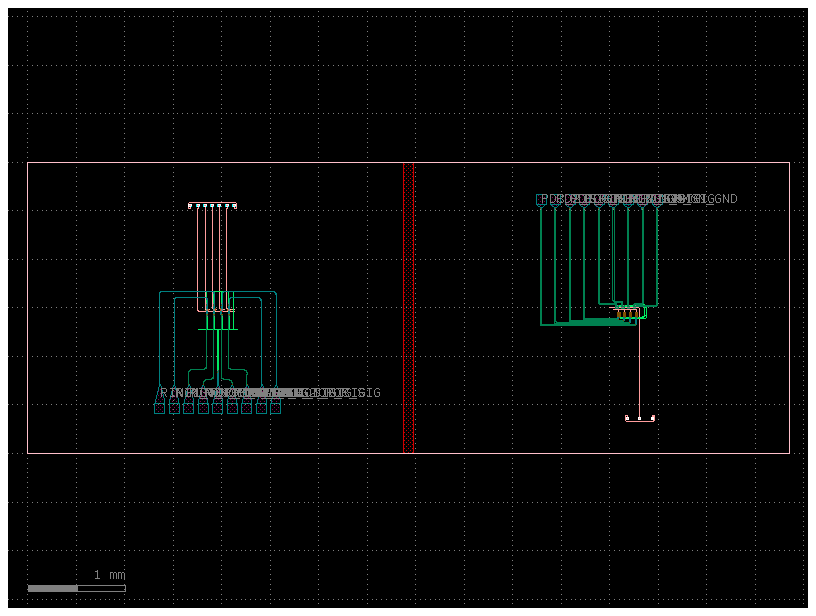

In [16]:
tx_component = gf.import_gds("tx.gds")
rx_component = gf.import_gds("fail.gds")

chip = make_wdm_tx_rx_floorplan(
    tx_component=tx_component,
    rx_component=rx_component,
)

chip.plot()
chip.write_gds("wdm_tx_rx_floorplan.gds")